# TP de Synthèse – Intelligence Artificielle avec Python
    Prédiction de l'annulation des réservations d'hôtel

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import ( train_test_split, GridSearchCV, StratifiedKFold, cross_val_score )

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report,confusion_matrix)

#  Chargement des données

In [2]:
import pandas as pd

# Chargement du jeu de données d'entraînement
donnees_train = pd.read_csv("Hotel Reservations.csv")

# Chargement du jeu de données de test
donnees_test = pd.read_csv("Donnees_test.csv")

donnees_train.head()
donnees_test.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,INN30000,1,0,1,2,Meal Plan 1,0,Room_Type 1,7,2017,10,19,Online,0,0,0,126.00,1
1,INN30001,2,0,0,2,Meal Plan 2,0,Room_Type 1,102,2017,10,16,Offline,0,0,0,101.50,0
2,INN30002,1,0,2,3,Meal Plan 1,0,Room_Type 1,96,2018,11,6,Corporate,0,0,0,79.00,1
3,INN30003,2,0,2,3,Meal Plan 1,0,Room_Type 1,118,2018,4,30,Online,0,0,0,97.75,1
4,INN30004,2,0,0,3,Meal Plan 1,0,Room_Type 1,25,2018,1,12,Offline,0,0,0,40.67,0


# Découverte du jeu de données

In [3]:

print("Dimensions du jeu d'entraînement :", donnees_train.shape)
print("Dimensions du jeu de test :", donnees_test.shape)

Dimensions du jeu d'entraînement : (29999, 19)
Dimensions du jeu de test : (6276, 18)


Le jeu de données d'entraînement contient 29 999 réservations réparties sur 19 variables.

Le jeu de données de test contient 6 276 réservations et 18 variable.


In [4]:
donnees_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29999 non-null  object 
 1   no_of_adults                          29999 non-null  int64  
 2   no_of_children                        29999 non-null  int64  
 3   no_of_weekend_nights                  29999 non-null  int64  
 4   no_of_week_nights                     29999 non-null  int64  
 5   type_of_meal_plan                     29999 non-null  object 
 6   required_car_parking_space            29999 non-null  int64  
 7   room_type_reserved                    29999 non-null  object 
 8   lead_time                             29999 non-null  int64  
 9   arrival_year                          29999 non-null  int64  
 10  arrival_month                         29999 non-null  int64  
 11  arrival_date   

L'analyse des informations générales montre que le jeu de données contient 29 999 observations réparties sur 19 variables.
Parmi ces variables :
13 variables** sont de type entier (`int64`), 1 variable est de type décimal (`float64`)et 5 variables sont de type texte (`object`).

On constate également que toutes les colonnes possèdent 29 999 valeurs non nulles. Le jeu de données ne contient donc aucune valeur manquante

## Statistiques descriptives

In [5]:
donnees_train.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,1.845862,0.105037,0.806127,2.202140,0.031301,85.503217,2017.821894,7.428548,15.583819,0.025668,0.022701,0.155139,103.412309,0.620687
std,0.518453,0.403747,0.868561,1.402214,0.174133,86.072456,0.382608,3.064046,8.723316,0.158144,0.353166,1.771725,35.043692,0.787359
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.500000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,127.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,375.500000,5.000000


Les statistiques descriptives permettent d'obtenir une première vision de la distribution des variables numériques.
On observe que le nombre moyen d'adultes par réservation est d'environ 1,85, ce qui indique que la majorité des réservations sont effectuées pour deux adultes. Le nombre moyen d'enfants est très faible 0,10, ce qui montre que la plupart des clients voyagent sans enfant.
La durée moyenne du séjour est d'environ 3 nuits, réparties entre les nuits de semaine (2,20 nuits) et les nuits de week-end (0,81 nuit).
La variable lead_time présente une moyenne de 85 jours,
Le prix moyen d'une chambre est d'environ 103 €par nuit. Cependant, les prix varient fortement selon les réservations, comme le montre l'écart-type de 35 € et un prix maximal de 375,50 €.
Les variables liées à l'historique des clients (no_of_previous_cancellations et no_of_previous_bookings_not_canceled) présentent des médianes égales à 0, ce qui indique que la majorité des clients n'ont pas d'historique de réservation dans l'hôtel.
Dans l'ensemble, ces statistiques montrent que le jeu de données est cohérent et fournit des informations variées qui pourront être exploitées pour construire un modèle de prédiction des annulations.

## Recherche des valeurs manquantes

In [6]:
donnees_train.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


L'analyse des valeurs manquantes montre que toutes les variables contiennent 29 999 valeurs renseignées.

Aucune colonne ne présente de donnée manquante. Cela signifie que le jeu de données est complet et qu'il ne sera pas nécessaire de supprimer des observations ou de remplacer des valeurs avant l'entraînement des modèles de Machine Learning.


## Étude de la variable cible

In [7]:
donnees_train["booking_status"].value_counts()

booking_status
Not_Canceled    20184
Canceled         9815
Name: count, dtype: int64

In [8]:
donnees_train["booking_status"].value_counts(normalize=True) * 100

booking_status
Not_Canceled    67.282243
Canceled        32.717757
Name: proportion, dtype: float64

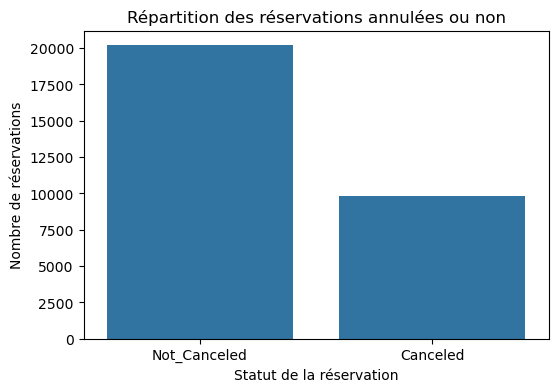

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=donnees_train,
    x="booking_status"
)

plt.title("Répartition des réservations annulées ou non")
plt.xlabel("Statut de la réservation")
plt.ylabel("Nombre de réservations")

plt.show()

L'étude de la variable cible montre que le jeu de données contient deux classes, ce qui confirme qu'il s'agit d'un problème de classification binaire.

On constate donc que les données sont légèrement déséquilibrées, avec environ deux fois plus de réservations non annulées que de réservations annulées. Ce déséquilibre n'est toutefois pas suffisamment important pour empêcher l'entraînement des modèles de Machine Learning.



## Analyse des variables numériques

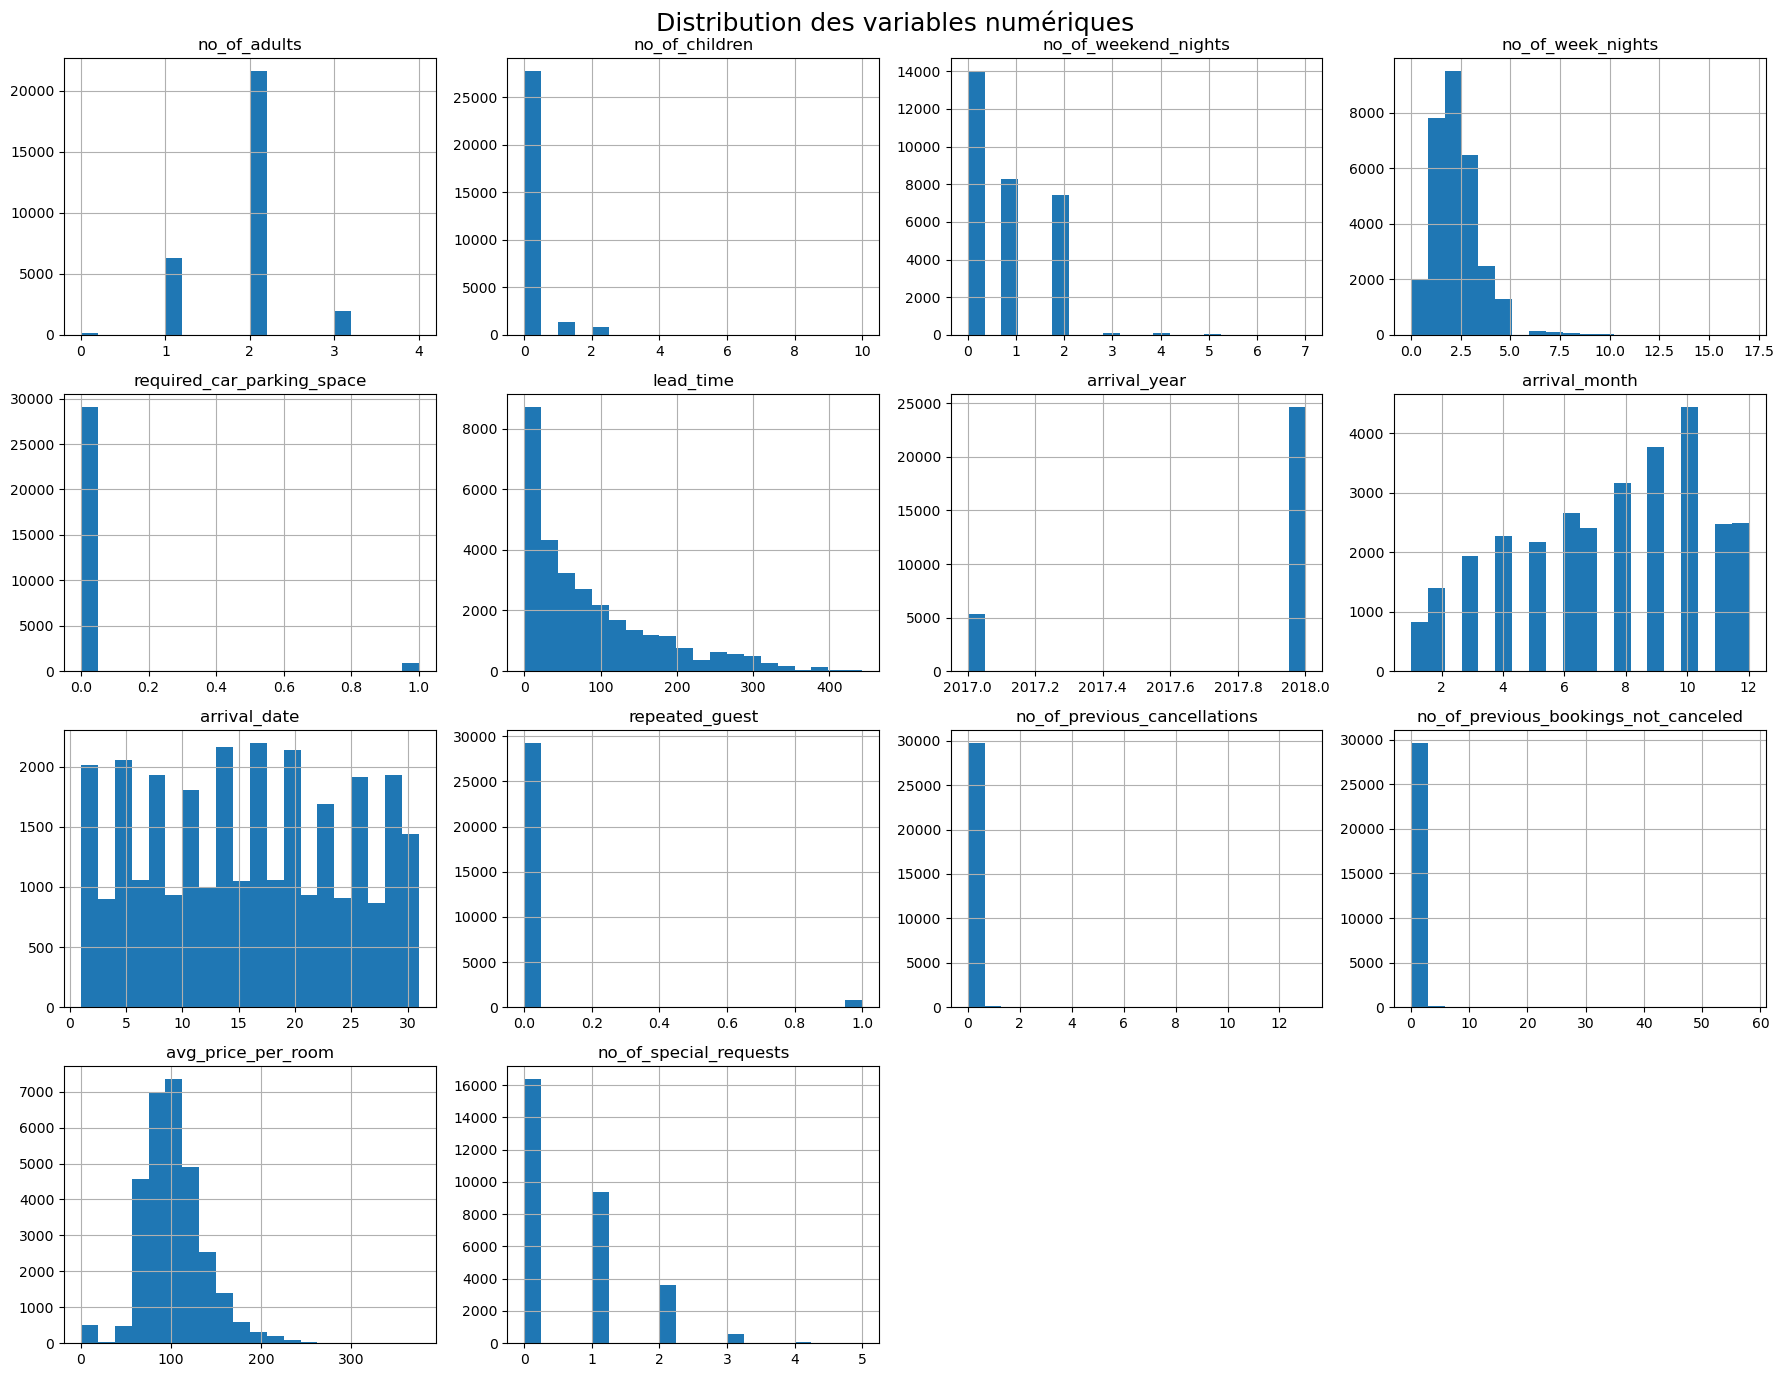

In [10]:
variables_numeriques = donnees_train.select_dtypes(include=["int64", "float64"]).columns


donnees_train[variables_numeriques].hist(
    figsize=(18,14),
    bins=20
)

plt.suptitle("Distribution des variables numériques", fontsize=18)

plt.tight_layout()

plt.show()

Les histogrammes permettent d'observer la distribution des différentes variables numériques du jeu de données.


## Analyse des valeurs aberrantes (Outliers)

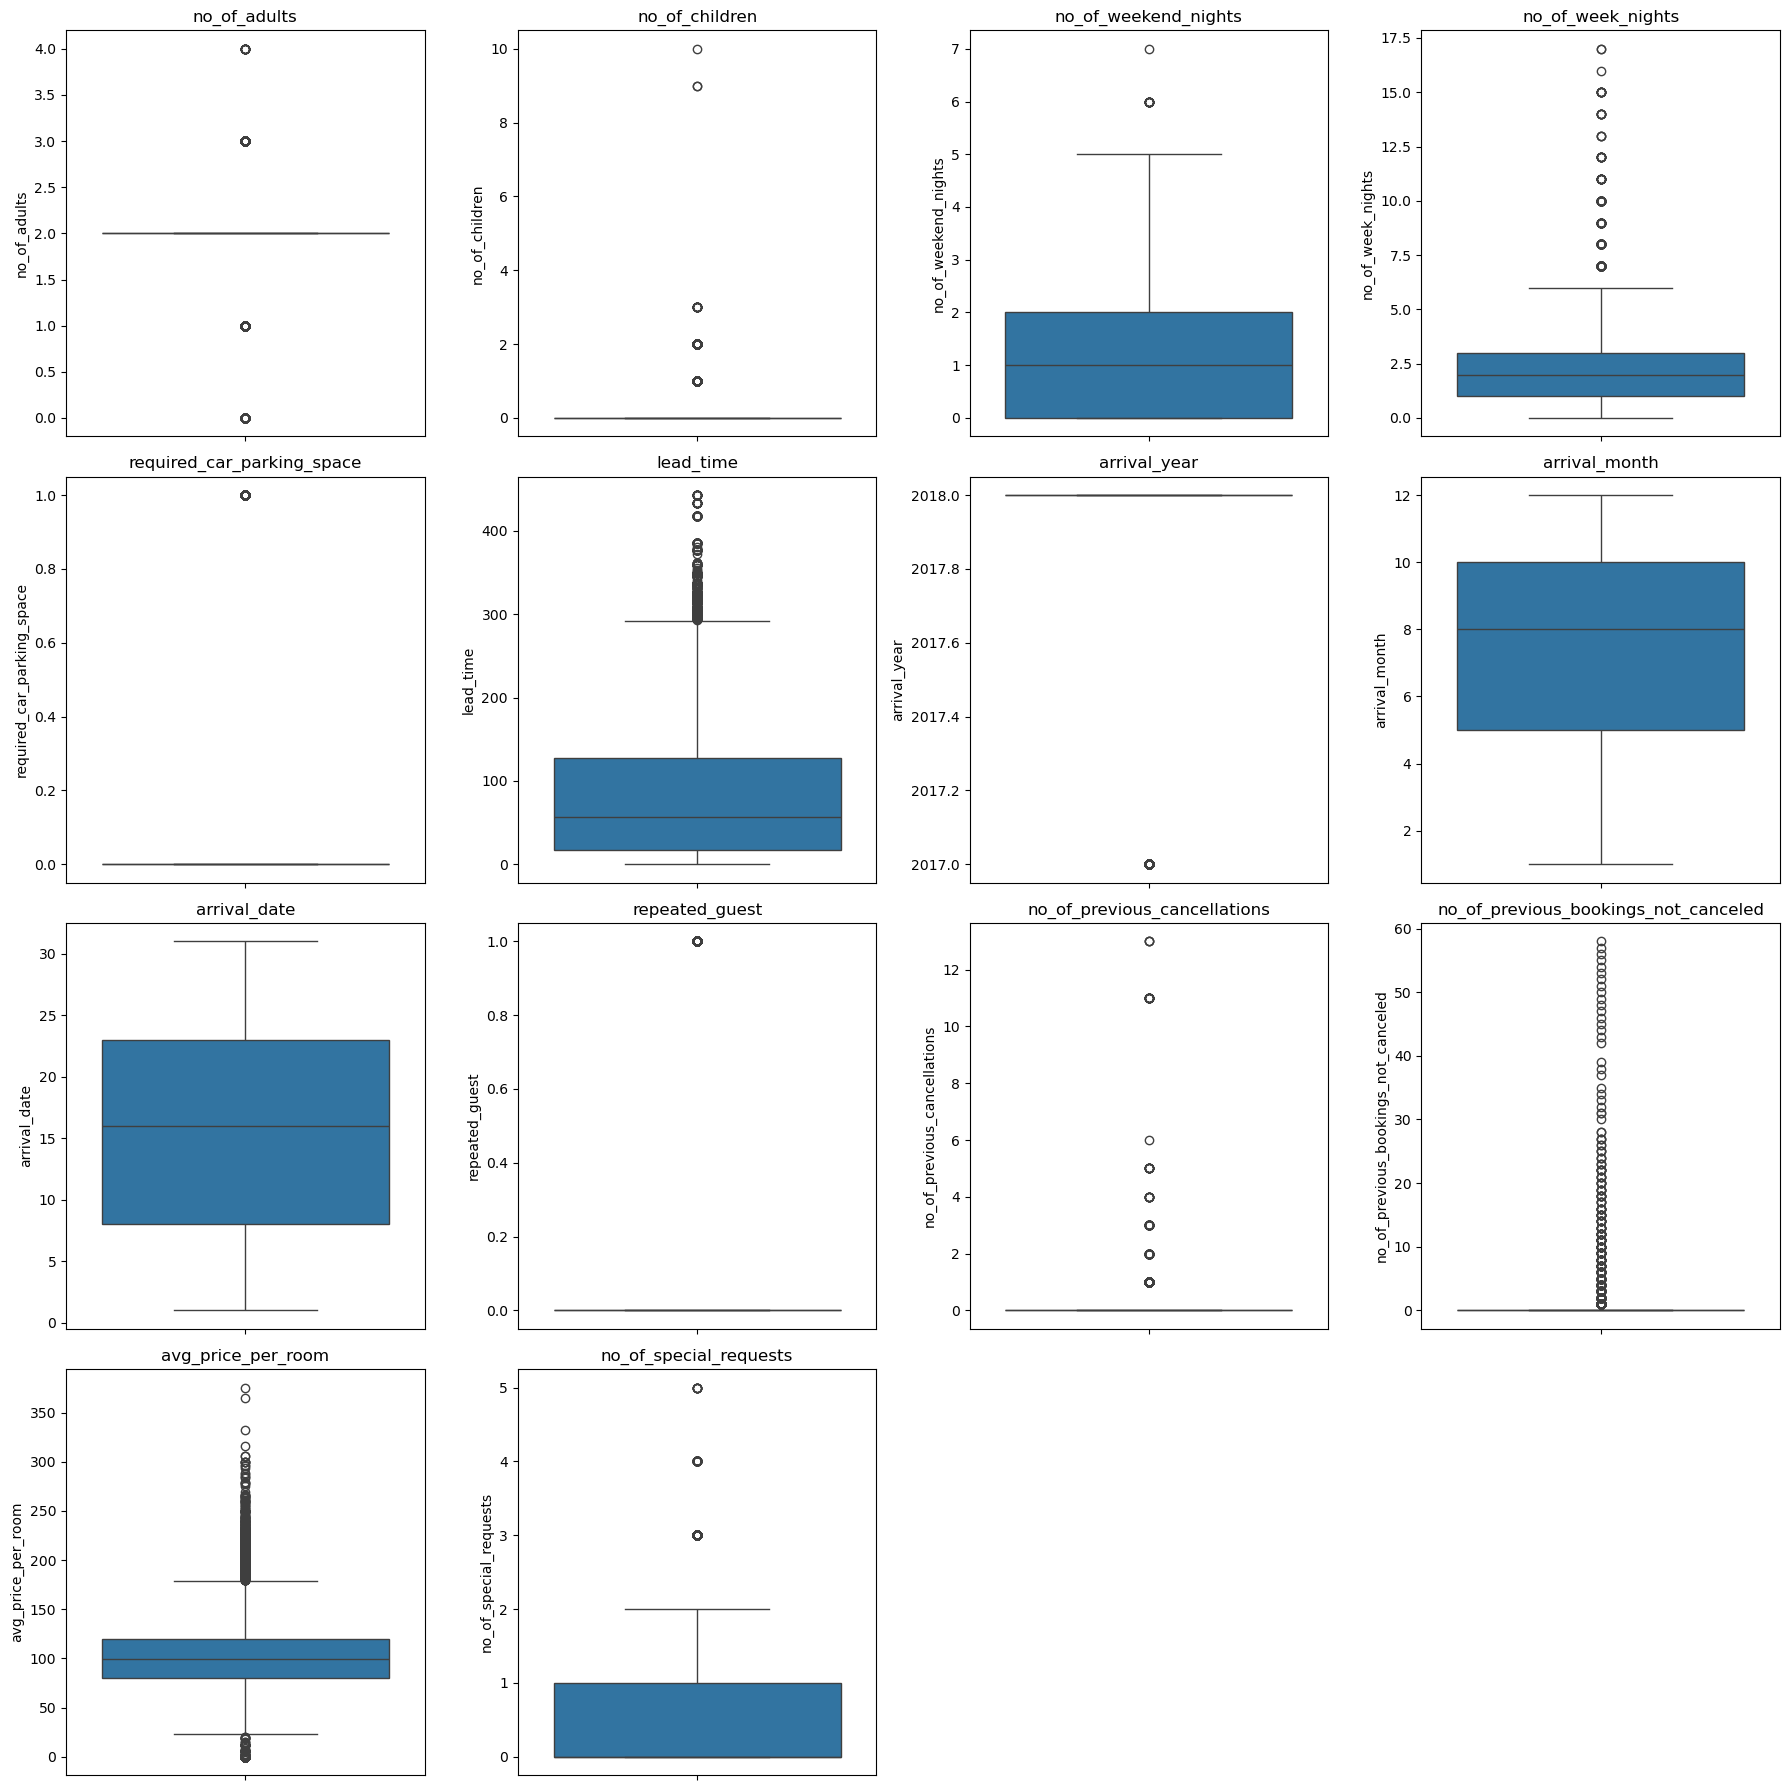

In [11]:
variables_numeriques = donnees_train.select_dtypes(include=["int64", "float64"]).columns

# Création des boxplots
plt.figure(figsize=(18,18))

for i, colonne in enumerate(variables_numeriques, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=donnees_train[colonne])
    plt.title(colonne)

plt.tight_layout()
plt.show()

Les boxplots montrent que plusieurs variables présentent des valeurs extrêmes.

## Analyse des variables catégorielles

In [12]:
variables_categorielles = donnees_train.select_dtypes(include="object").columns

variables_categorielles

Index(['Booking_ID', 'type_of_meal_plan', 'room_type_reserved',
       'market_segment_type', 'booking_status'],
      dtype='object')

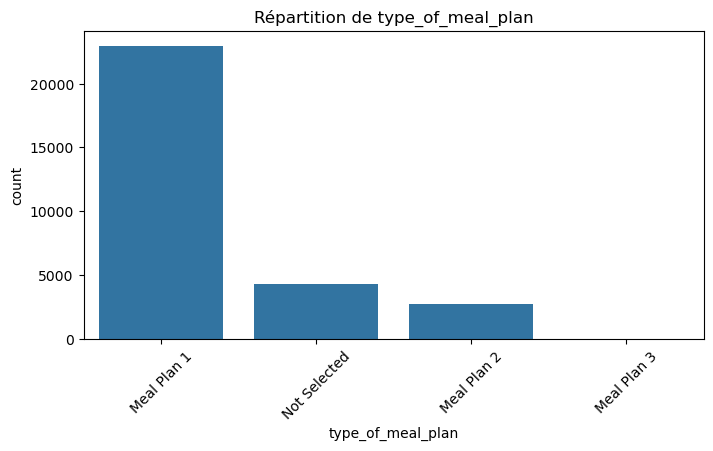

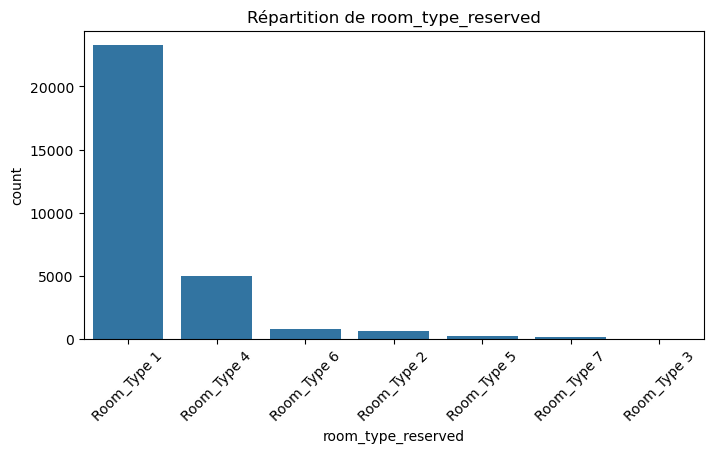

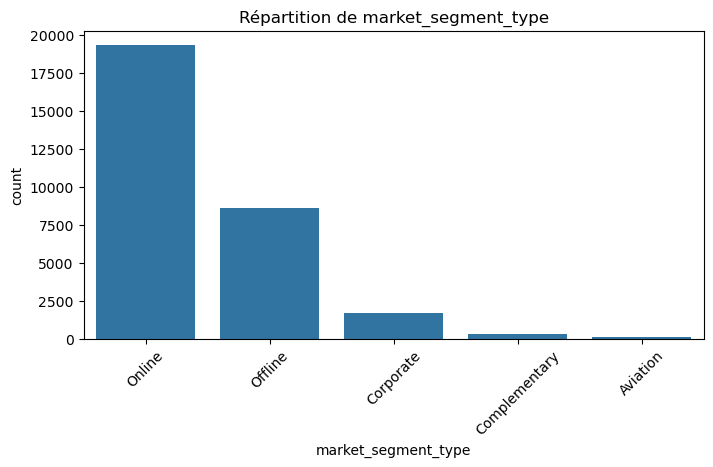

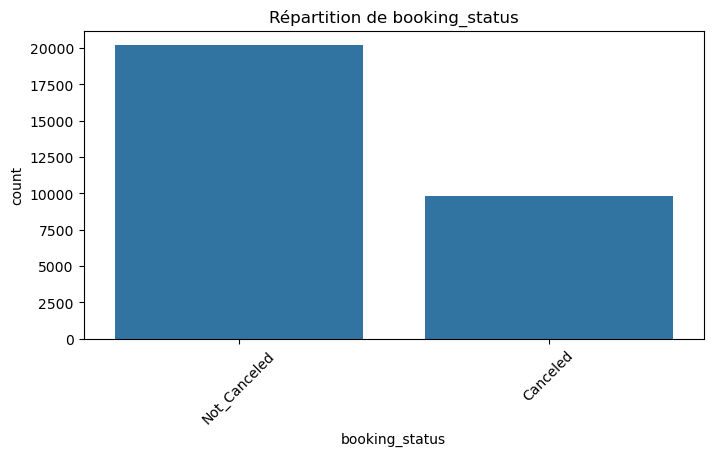

In [16]:
variables_categorielles = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type",
    "booking_status"
]

for colonne in variables_categorielles:

    plt.figure(figsize=(8,4))

    sns.countplot( data=donnees_train, x=colonne, order=donnees_train[colonne].value_counts().index)

    plt.title(f"Répartition de {colonne}")
    plt.xticks(rotation=45)

    plt.show()

# Analyse des corrélations
Avant de construire les modèles de Machine Learning, il est utile d'étudier les relations entre les variables numériques.

La matrice de corrélation permet de mesurer l'intensité de la relation entre deux variables.

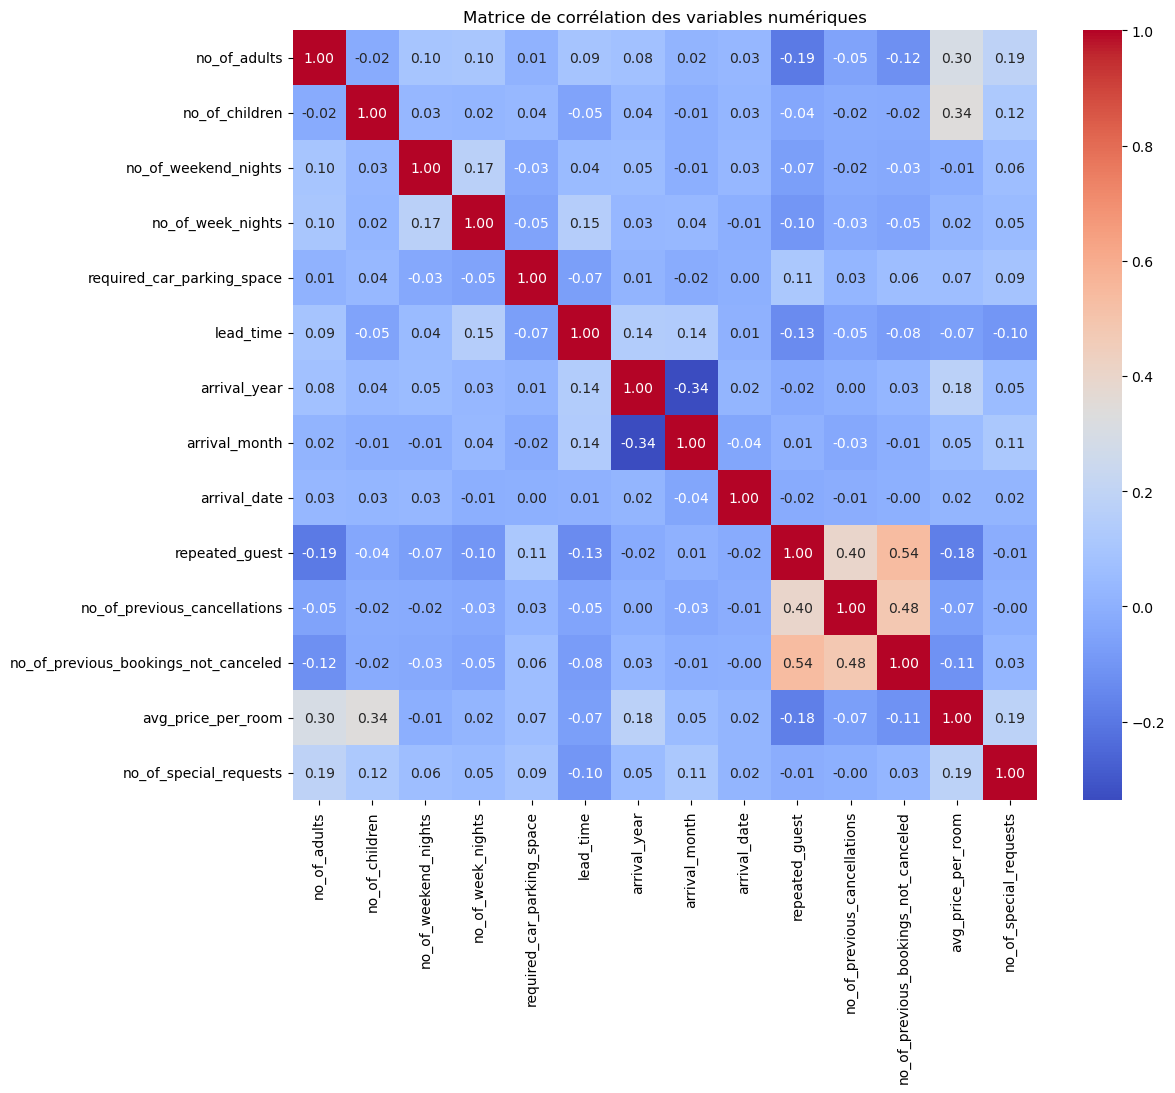

In [17]:
variables_numeriques = donnees_train.select_dtypes(include=["int64", "float64"])

corr = variables_numeriques.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matrice de corrélation des variables numériques")

plt.show()

La matrice de corrélation permet d'étudier les relations entre les différentes variables numériques du jeu de données.

# Prétraitement des données

In [18]:
donnees_train = donnees_train.drop("Booking_ID", axis=1)
donnees_test = donnees_test.drop("Booking_ID", axis=1)

## Identification des variables numériques et catégorielles

In [19]:
X = donnees_train.drop("booking_status", axis=1)

y = donnees_train["booking_status"]

print(X.shape)
print(y.shape)

(29999, 17)
(29999,)


## Identification des variables numériques et catégorielles

In [20]:
variables_numeriques = X.select_dtypes(include=["int64","float64"]).columns

variables_categorielles = X.select_dtypes(include="object").columns

print("Variables numériques :")
print(variables_numeriques)

print()

print("Variables catégorielles :")
print(variables_categorielles)

Variables numériques :
Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')

Variables catégorielles :
Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'], dtype='object')


## Encodage des variables catégorielles

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessing = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categorielles)
    ],
    remainder="passthrough"
)

Les variables catégorielles sont converties automatiquement en variables numériques grâce à la technique du One-Hot Encoding.
Cette transformation est indispensable pour permettre aux algorithmes de Machine Learning de traiter correctement les informations qualitatives.

## Séparation des données

In [22]:
from sklearn.model_selection import train_test_split


X_train, X_valid, y_train, y_valid = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

print("Jeu d'entraînement :", X_train.shape)
print("Jeu de validation :", X_valid.shape)

Jeu d'entraînement : (23999, 17)
Jeu de validation : (6000, 17)


Le jeu de données est séparé en deux ensembles.

Le jeu d'entraînement est utilisé pour apprendre les relations entre les variables explicatives et la variable cible.
Le jeu de validation permet ensuite d'évaluer objectivement les performances des modèles sur des données qu'ils n'ont jamais rencontrées pendant leur apprentissage.

# Construction du premier modèle : Régression Logistique

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessing = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categorielles),
        ("num", StandardScaler(), variables_numeriques)
    ]
)

In [25]:
pipeline_log = Pipeline([
    ("preprocessing", preprocessing),
    ("modele", LogisticRegression(max_iter=5000))
])

pipeline_log.fit(X_train, y_train)
pred_log = pipeline_log.predict(X_valid)

In [26]:
pipeline_log.fit(X_train, y_train)

pred_log = pipeline_log.predict(X_valid)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_valid, pred_log))
print("Precision :", precision_score(y_valid, pred_log, pos_label="Canceled"))
print("Recall :", recall_score(y_valid, pred_log, pos_label="Canceled"))
print("F1-score :", f1_score(y_valid, pred_log, pos_label="Canceled"))

Accuracy : 0.8071666666666667
Precision : 0.7393111638954869
Recall : 0.6342333163525217
F1-score : 0.6827529476281875


In [28]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

modeles = {
    "Régression Logistique": LogisticRegression(max_iter=5000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Réseau de neurones": MLPClassifier(max_iter=500, random_state=42)
}

resultats = []

for nom, modele in modeles.items():
    if nom == "Naive Bayes":

        X_train_prepared = preprocessing.fit_transform(X_train)
        X_valid_prepared = preprocessing.transform(X_valid)

        if hasattr(X_train_prepared, "toarray"):
            X_train_prepared = X_train_prepared.toarray()
            X_valid_prepared = X_valid_prepared.toarray()

        modele.fit(X_train_prepared, y_train)
        predictions = modele.predict(X_valid_prepared)

    else:

        pipeline = Pipeline([
            ("preprocessing", preprocessing),
            ("modele", modele)
        ])

        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_valid)

    resultats.append([
        nom,
        accuracy_score(y_valid, predictions),
        precision_score(y_valid, predictions, pos_label="Canceled"),
        recall_score(y_valid, predictions, pos_label="Canceled"),
        f1_score(y_valid, predictions, pos_label="Canceled")
    ])

resultats = pd.DataFrame(
    resultats,
    columns=["Modèle", "Accuracy", "Precision", "Recall", "F1-score"]
)

resultats.sort_values(by="Accuracy", ascending=False)

,Modèle,Accuracy,Precision,Recall,F1-score
4,Random Forest,0.900167,0.875551,0.809985,0.841492
3,Arbre de décision,0.867167,0.788043,0.812532,0.800100
6,Réseau de neurones,0.862667,0.816917,0.747835,0.780851
2,KNN,0.848000,0.777602,0.749873,0.763485
5,SVM,0.843667,0.812691,0.678553,0.739589
0,Régression Logistique,0.807167,0.739311,0.634233,0.682753
1,Naive Bayes,0.402500,0.349536,0.959755,0.512444


# Comparaison des modèles

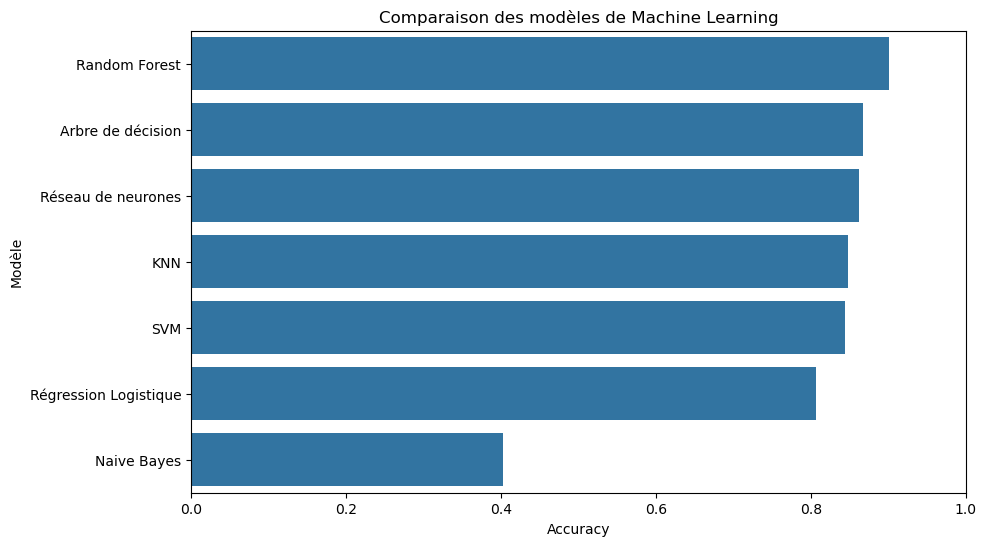

In [29]:
plt.figure(figsize=(10,6))

sns.barplot( data=resultats.sort_values("Accuracy", ascending=False), x="Accuracy", y="Modèle")

plt.title("Comparaison des modèles de Machine Learning")
plt.xlim(0,1)

plt.show()

Le graphique confirme que le modèle Random Forest obtient les meilleures performances. Il sera donc utilisé pour réaliser les prédictions sur les données de test.

# Prédictions sur le jeu de test

In [31]:
pipeline_final = Pipeline([
    ("preprocessing", preprocessing),
    ("modele", RandomForestClassifier(random_state=42))
])

pipeline_final.fit(X, y)

predictions = pipeline_final.predict(donnees_test)

print(predictions[:10])

['Not_Canceled' 'Canceled' 'Not_Canceled' 'Not_Canceled' 'Not_Canceled'
 'Not_Canceled' 'Not_Canceled' 'Not_Canceled' 'Not_Canceled' 'Canceled']


In [32]:
submission = pd.DataFrame({
    "booking_status": predictions
})

submission.to_csv("Boufnina.csv", index=False, header=False)

print("Les fichiers ont été créés avec succès !")

Les fichiers ont été créés avec succès !
